In [1]:
!pip install tensorflow

In [2]:
!pip install torch==2.6.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118
INFO: pip is looking at multiple versions of torch to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 27.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 40.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 81.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 14.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 MB 7.4 MB/s e

In [3]:
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.6.0+cu118.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-2.6.0+cu118.html
!pip install pyg-lib -f https://data.pyg.org/whl/torch-2.6.0+cu118.html
!pip install torch-geometric

Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu118.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 82.5 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu118.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 17.8 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu118.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 53.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.3 MB/s eta 0:00:00


In [4]:
import torch
import torch_sparse
import torch_geometric
import pyg_lib

print("Torch:", torch.__version__)
print("Torch Sparse:", torch_sparse.__version__)
print("Torch Geometric:", torch_geometric.__version__)
print("Pyg Lib:", pyg_lib.__version__)


Torch: 2.6.0+cu118
Torch Sparse: 0.6.18+pt26cu118
Torch Geometric: 2.6.1
Pyg Lib: 0.4.0+pt26cu118


In [5]:
import torch

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Device:", torch.cuda.get_device_name(0))


PyTorch Version: 2.6.0+cu118
CUDA Available: True
GPU Device: Tesla T4


In [6]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv, global_mean_pool
from torch.nn import TransformerEncoder, TransformerEncoderLayer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from itertools import combinations


In [10]:
try:
    df1 = pd.read_csv("/content/GDSC1.csv", engine='python', on_bad_lines='skip')
    df2 = pd.read_csv("/content/GDSC2.csv", engine='python', on_bad_lines='skip')
except ParserError as e:
    print(f"ParserError: {e}")
    print("Attempting to read with different parameters...")
    try:
        df1 = pd.read_csv("/content/GDSC1.csv", engine='python', quotechar='"', on_bad_lines='skip')
        df2 = pd.read_csv("/content/GDSC2.csv", engine='python', quotechar='"', on_bad_lines='skip')
    except Exception as e:
        print(f"Failed to read CSV files even with alternative parameters: {e}")

In [11]:
df1.drop(columns=['log_max_conc_tested','log_max_conc_tested_2'],inplace=True,errors='ignore')
df2.drop(columns=['log_max_conc_tested','log_max_conc_tested_2'],inplace=True,errors='ignore')

In [12]:
df=pd.concat([df1,df2],ignore_index=True)

In [13]:
print(df1.shape)
print(df2.shape)
print(df.shape)
df.columns

(200920, 20)
(239611, 20)
(440531, 20)


Index(['Drug name', 'Drug ID', 'Drug target', 'Target Pathway', 'Feature Name',
       'n_feature_pos', 'n_feature_neg', 'ic50_effect_size',
       'log_ic50_mean_pos', 'log_ic50_mean_neg', 'feature_ic50_t_pval',
       'feature_delta_mean_ic50', 'feature_pos_ic50_var',
       'feature_neg_ic50_var', 'feature_pval', 'tissue_pval', 'msi_pval',
       'fdr', 'Tissue Type', 'Screening Set'],
      dtype='object')

In [14]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['Feature Name', 'Drug name', 'Tissue Type', 'Screening Set']
for col in categorical_cols:
    if col in df.columns:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

df.head(3)



,Drug name,Drug ID,Drug target,Target Pathway,Feature Name,n_feature_pos,n_feature_neg,ic50_effect_size,log_ic50_mean_pos,log_ic50_mean_neg,feature_ic50_t_pval,feature_delta_mean_ic50,feature_pos_ic50_var,feature_neg_ic50_var,feature_pval,tissue_pval,msi_pval,fdr,Tissue Type,Screening Set
0,137,1003,TOP1,DNA replication,0,16,949,0.559182,-1.248911,-2.274636,0.020317,1.025725,1.571565,1.838187,0.063782,0.0,0.104659,63.449939,0,1
1,137,1003,TOP1,DNA replication,1,7,958,0.373240,-2.938700,-2.252653,0.406394,-0.686047,2.029013,1.836828,0.862946,0.0,0.105291,91.677351,0,1
2,137,1003,TOP1,DNA replication,2,11,954,0.159295,-1.968064,-2.260968,0.531192,0.292904,1.486441,1.842088,0.848725,0.0,0.105290,91.380248,0,1


In [15]:


df.isnull().sum()

,0
Drug name,0
Drug ID,0
Drug target,29907
Target Pathway,1780
Feature Name,0
n_feature_pos,0
n_feature_neg,0
ic50_effect_size,0
log_ic50_mean_pos,0
log_ic50_mean_neg,0


In [16]:
df_train, df_val = train_test_split(df, test_size=0.5, random_state=42, shuffle=True)

In [17]:
feature_cols = [
    'n_feature_pos',
    'log_ic50_mean_pos',
    'log_ic50_mean_neg',
    'feature_pos_ic50_var',
    'feature_neg_ic50_var',
    'feature_delta_mean_ic50',
    'feature_ic50_t_pval',
    'feature_pval',
    'tissue_pval',
    'msi_pval'
]
feature_cols = [col for col in feature_cols if col in df_train.columns]
target_col = 'ic50_effect_size'

scaler = StandardScaler()
df_train[feature_cols] = scaler.fit_transform(df_train[feature_cols])
df_val[feature_cols] = scaler.transform(df_val[feature_cols])

In [18]:
def build_edge_index(df):
    row_idx, col_idx = [], []
    feature_to_indices = df.groupby("Feature Name").indices

    for idx_list in feature_to_indices.values():
        if len(idx_list) < 2:
            continue
        pairs = list(combinations(idx_list, 2))
        sampled = pairs[:500]  # Limit to 500 per feature group to reduce size
        row_idx.extend([i for i, j in sampled] + [j for i, j in sampled])
        col_idx.extend([j for i, j in sampled] + [i for i, j in sampled])

    return torch.tensor([row_idx, col_idx], dtype=torch.long)

def build_data(df):
    x = torch.tensor(df[feature_cols].values, dtype=torch.float32)
    y = torch.tensor(df[target_col].values, dtype=torch.float32)
    edge_index = build_edge_index(df)
    return Data(x=x, y=y, edge_index=edge_index)


In [19]:
data_train = build_data(df_train)
data_val = build_data(df_val)

In [20]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)


In [21]:
from torch_geometric.nn import global_mean_pool
class GNNTransformerModel(nn.Module):
    def __init__(self, in_channels, hidden_dim, n_heads, n_transformer_layers):
        super().__init__()
        self.gnn = GATConv(in_channels, hidden_dim, heads=4, concat=False)
        self.pos_encoder = PositionalEncoding(hidden_dim)
        encoder_layer = TransformerEncoderLayer(d_model=hidden_dim, nhead=n_heads, batch_first=True)
        self.transformer = TransformerEncoder(encoder_layer, num_layers=n_transformer_layers)
        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        batch = data.batch if hasattr(data, 'batch') else torch.zeros(x.size(0), dtype=torch.long, device=x.device)

    # GNN
        x = self.gnn(x, edge_index)
        x = F.relu(x)

    # Global pooling to reduce sequence size before transformer
        x_pooled = global_mean_pool(x, batch)  # [batch_size, hidden_dim]

    # Add dummy seq_len=1 dimension
        x_trans = x_pooled.unsqueeze(1)  # [batch_size, 1, hidden_dim]
        x_trans = self.pos_encoder(x_trans)

    # Transformer expects [batch_size, seq_len, d_model]
        x_trans = self.transformer(x_trans)  # [batch_size, 1, hidden_dim]

    # Remove seq_len dim
        x_out = x_trans.squeeze(1)  # [batch_size, hidden_dim]

        return self.regressor(x_out).view(-1)  # [batch_size]


In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_train = data_train.to(device)
data_val = data_val.to(device)

model = GNNTransformerModel(
    in_channels=data_train.num_node_features,
    hidden_dim=128,
    n_heads=8,
    n_transformer_layers=2
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()

In [23]:
from torch_geometric.loader import NeighborLoader
train_loader = NeighborLoader(
    data_train,
    num_neighbors=[15, 10],
    batch_size=1024,
    shuffle=True,
)


In [24]:
# from sklearn.metrics import r2_score, mean_absolute_error
# val_data = data_val.to(device)
# accum_steps = 4  # gradient accumulation to simulate larger batch

# for epoch in range(1, 31):
#     model.train()
#     total_loss = 0
#     optimizer.zero_grad()

#     for i, batch in enumerate(train_loader):
#         batch = batch.to(device)

#         # Forward
#         pred = model(batch)
#         target = batch.y[:pred.size(0)]

#         loss = criterion(pred, target) / accum_steps
#         loss.backward()

#         if (i + 1) % accum_steps == 0:
#             optimizer.step()
#             optimizer.zero_grad()
#             torch.cuda.empty_cache()

#         total_loss += loss.item() * accum_steps

#     # Evaluation on full val_data
#     model.eval()
#     with torch.no_grad():
#         val_pred = model(val_data)
#         val_target = val_data.y[:val_pred.size(0)]
#         val_loss = criterion(val_pred, val_target)
#         r2 = r2_score(val_target.cpu(), val_pred.cpu())
#         mae = mean_absolute_error(val_target.cpu(), val_pred.cpu())

#     print(f"Epoch {epoch:03d} | Train Loss: {total_loss:.4f} | Val Loss: {val_loss.item():.4f} | R2: {r2:.4f} | MAE: {mae:.4f}")



In [25]:
from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler()


<ipython-input-25-2479615527>:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import torch
from torch_geometric.data import Data
from itertools import combinations

# List of relevant columns
feature_cols = [
    'n_feature_pos',
    'log_ic50_mean_pos',
    'log_ic50_mean_neg',
    'feature_pos_ic50_var',
    'feature_neg_ic50_var',
    'feature_delta_mean_ic50',
    'feature_ic50_t_pval',
    'feature_pval',
    'tissue_pval',
    'msi_pval'
]
target_col = 'ic50_effect_size'

# Filter existing features
feature_cols = [col for col in feature_cols if col in df.columns]

# Encode categorical columns
categorical_cols = ['Feature Name', 'Drug name', 'Tissue Type', 'Screening Set']
for col in categorical_cols:
    if col in df.columns:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Split DataFrame into train and validation sets
df_train, df_val = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)

# Normalize features
scaler = StandardScaler()
df_train[feature_cols] = scaler.fit_transform(df_train[feature_cols])
df_val[feature_cols] = scaler.transform(df_val[feature_cols])

# --- Graph Construction ---
def build_edge_index(df):
    row_idx, col_idx = [], []
    feature_to_indices = df.groupby("Feature Name").indices
    for idx_list in feature_to_indices.values():
        if len(idx_list) < 2:
            continue
        pairs = list(combinations(idx_list, 2))
        sampled = pairs[:500]  # limit edges per group
        row_idx.extend([i for i, j in sampled] + [j for i, j in sampled])
        col_idx.extend([j for i, j in sampled] + [i for i, j in sampled])
    return torch.tensor([row_idx, col_idx], dtype=torch.long)

def build_data(df):
    x = torch.tensor(df[feature_cols].values, dtype=torch.float32)
    y = torch.tensor(df[target_col].values, dtype=torch.float32)
    edge_index = build_edge_index(df)
    return Data(x=x, y=y, edge_index=edge_index)

# --- Build PyG Data objects ---
data_train = build_data(df_train)
data_val = build_data(df_val)


In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_train = data_train.to(device)
data_val = data_val.to(device)


In [1]:
!pip install --upgrade transformers torchvision

In [1]:
# Install dependencies
!pip install torch==2.6.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.6.0+cu118.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-2.6.0+cu118.html
!pip install pyg-lib -f https://data.pyg.org/whl/torch-2.6.0+cu118.html
!pip install torch-geometric

#  Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from torch_geometric.data import Data
from torch_geometric.nn import GATConv, global_mean_pool
from torch_geometric.loader import NeighborLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from itertools import combinations

#  Load GDSC1 + GDSC2
df1 = pd.read_csv("/content/GDSC1.csv", engine='python', on_bad_lines='skip')
df2 = pd.read_csv("/content/GDSC2.csv", engine='python', on_bad_lines='skip')

# Drop irrelevant columns
df1.drop(columns=['log_max_conc_tested','log_max_conc_tested_2'], inplace=True, errors='ignore')
df2.drop(columns=['log_max_conc_tested','log_max_conc_tested_2'], inplace=True, errors='ignore')

df = pd.concat([df1, df2], ignore_index=True)

#  Encode categorical columns
categorical_cols = ['Feature Name', 'Drug name', 'Tissue Type', 'Screening Set']
for col in categorical_cols:
    if col in df.columns:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

#  Select features and target
feature_cols = [
    'n_feature_pos', 'log_ic50_mean_pos', 'log_ic50_mean_neg',
    'feature_pos_ic50_var', 'feature_neg_ic50_var',
    'feature_delta_mean_ic50', 'feature_ic50_t_pval',
    'feature_pval', 'tissue_pval', 'msi_pval'
]
feature_cols = [col for col in feature_cols if col in df.columns]
target_col = 'ic50_effect_size'

# Train-test split and scaling
df_train, df_val = train_test_split(df, test_size=0.2, random_state=42)
scaler = StandardScaler()
df_train[feature_cols] = scaler.fit_transform(df_train[feature_cols])
df_val[feature_cols] = scaler.transform(df_val[feature_cols])

# Graph Construction
def build_edge_index(df):
    row_idx, col_idx = [], []
    feature_to_indices = df.groupby("Feature Name").indices
    for idx_list in feature_to_indices.values():
        if len(idx_list) < 2:
            continue
        pairs = list(combinations(idx_list, 2))[:500]
        row_idx.extend([i for i, j in pairs] + [j for i, j in pairs])
        col_idx.extend([j for i, j in pairs] + [i for i, j in pairs])
    return torch.tensor([row_idx, col_idx], dtype=torch.long)

def build_data(df):
    x = torch.tensor(df[feature_cols].values, dtype=torch.float32)
    y = torch.tensor(df[target_col].values, dtype=torch.float32)
    edge_index = build_edge_index(df)
    return Data(x=x, y=y, edge_index=edge_index)

data_train = build_data(df_train)
data_val = build_data(df_val)

#  Model Definition
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)

class GNNTransformerModel(nn.Module):
    def __init__(self, in_channels, hidden_dim=128, n_heads=8, n_transformer_layers=2):
        super().__init__()
        self.gnn = GATConv(in_channels, hidden_dim, heads=4, concat=False)
        self.pos_encoder = PositionalEncoding(hidden_dim)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=n_heads, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_transformer_layers)
        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        batch = getattr(data, 'batch', torch.zeros(x.size(0), dtype=torch.long, device=x.device))

        x = F.relu(self.gnn(x, edge_index))
        x_pooled = global_mean_pool(x, batch)  # [batch_size, hidden_dim]
        x_trans = x_pooled.unsqueeze(1)  # Add seq_len=1
        x_trans = self.pos_encoder(x_trans)
        x_trans = self.transformer(x_trans).squeeze(1)  # [batch_size, hidden_dim]
        return self.regressor(x_trans).view(-1)

#  Training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GNNTransformerModel(in_channels=data_train.num_node_features).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()

data_train = data_train.to(device)
data_val = data_val.to(device)

train_loader = NeighborLoader(data_train, num_neighbors=[15, 10], batch_size=1024, shuffle=True)

#  Training Loop
for epoch in range(1, 21):
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch)
        target = batch.y[:out.size(0)]
        loss = criterion(out, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Validation
    model.eval()
    with torch.no_grad():
        pred = model(data_val)
        true = data_val.y[:pred.size(0)]
        val_loss = criterion(pred, true)
        r2 = r2_score(true.cpu(), pred.cpu())
        mae = mean_absolute_error(true.cpu(), pred.cpu())

    print(f"Epoch {epoch:02d} | Train Loss: {total_loss:.4f} | Val Loss: {val_loss.item():.4f} | R²: {r2:.4f} | MAE: {mae:.4f}")


Looking in indexes: https://download.pytorch.org/whl/cu118
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu118.html
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu118.html
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu118.html


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


Epoch 01 | Train Loss: 23.4394 | Val Loss: 0.0023 | R²: nan | MAE: 0.0485


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


Epoch 02 | Train Loss: 18.8929 | Val Loss: 0.0115 | R²: nan | MAE: 0.1072


...

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


Epoch 18 | Train Loss: 17.1907 | Val Loss: 0.0027 | R²: nan | MAE: 0.0520


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


Epoch 19 | Train Loss: 16.9696 | Val Loss: 0.0089 | R²: nan | MAE: 0.0943
Epoch 20 | Train Loss: 17.1349 | Val Loss: 0.0024 | R²: nan | MAE: 0.0489


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [4]:
from sklearn.model_selection import train_test_split

# Assuming X and y are your data and labels
X = df[feature_cols]
y = df[target_col]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")

Train size: 376373
Validation size: 94094


In [29]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.utils import shuffle

# --------------------------------------------
# 1. Simulate Dataset (replace this with your own X and y)
# --------------------------------------------
# For demo: X = 10 features, 470,467 samples
X = np.random.rand(470467, 10)
y = X @ np.random.rand(10) + np.random.normal(0, 0.1, size=(470467,))  # Linear + noise

# Shuffle data before splitting (important for real-world data)
X, y = shuffle(X, y, random_state=42)

# --------------------------------------------
# 2. Train-test split
# --------------------------------------------
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f" Total samples: {len(X)}")
print(f" Train samples: {len(X_train)}")
print(f" Validation samples: {len(X_val)}")

# --------------------------------------------
# 3. Fit model on training data
# --------------------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

print("\n Model training complete.\n")

# --------------------------------------------
# 4. Predict in batches & calculate R² across all validation data
# --------------------------------------------
batch_size = 1024  # simulate loader
y_val_all = []
y_pred_all = []

print(f" Predicting validation in batches of {batch_size}...\n")
for i in range(0, len(X_val), batch_size):
    X_batch = X_val[i:i+batch_size]
    y_batch = y_val[i:i+batch_size]

    y_pred = model.predict(X_batch)

    y_val_all.extend(y_batch)
    y_pred_all.extend(y_pred)

print(f" Completed prediction across {len(y_val_all)} samples.")

# --------------------------------------------
# 5. Final evaluation
# --------------------------------------------
y_val_all = np.array(y_val_all)
y_pred_all = np.array(y_pred_all)

r2 = r2_score(y_val_all, y_pred_all)
print(f"\n Final R² Score on full validation set: {r2:.4f}")


 Total samples: 470467
 Train samples: 376373
 Validation samples: 94094

 Model training complete.

 Predicting validation in batches of 1024...

 Completed prediction across 94094 samples.

 Final R² Score on full validation set: 0.9625


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv, global_mean_pool
from torch.nn import TransformerEncoder, TransformerEncoderLayer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from itertools import combinations
import pandas as pd
import numpy as np


In [30]:
df1 = pd.read_csv("/content/GDSC1.csv", engine='python', on_bad_lines='skip')
df2 = pd.read_csv("/content/GDSC2.csv", engine='python', on_bad_lines='skip')

df1.drop(columns=['log_max_conc_tested','log_max_conc_tested_2'], inplace=True, errors='ignore')
df2.drop(columns=['log_max_conc_tested','log_max_conc_tested_2'], inplace=True, errors='ignore')

df = pd.concat([df1, df2], ignore_index=True)

print(" GDSC1 shape:", df1.shape)
print(" GDSC2 shape:", df2.shape)
print(" Combined shape:", df.shape)

categorical_cols = ['Feature Name', 'Drug name', 'Tissue Type', 'Screening Set']
for col in categorical_cols:
    if col in df.columns:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))


 GDSC1 shape: (200920, 20)
 GDSC2 shape: (269547, 20)
 Combined shape: (470467, 20)


In [8]:
feature_cols = [
    'n_feature_pos', 'log_ic50_mean_pos', 'log_ic50_mean_neg',
    'feature_pos_ic50_var', 'feature_neg_ic50_var',
    'feature_delta_mean_ic50', 'feature_ic50_t_pval', 'feature_pval',
    'tissue_pval', 'msi_pval'
]
feature_cols = [col for col in feature_cols if col in df.columns]
target_col = 'ic50_effect_size'

df_train, df_val = train_test_split(df, test_size=0.5, random_state=42, shuffle=True)

scaler = StandardScaler()
df_train[feature_cols] = scaler.fit_transform(df_train[feature_cols])
df_val[feature_cols] = scaler.transform(df_val[feature_cols])


In [9]:
def build_edge_index(df):
    row_idx, col_idx = [], []
    feature_to_indices = df.groupby("Feature Name").indices
    for idx_list in feature_to_indices.values():
        if len(idx_list) < 2:
            continue
        pairs = list(combinations(idx_list, 2))[:500]  # reduce memory
        row_idx += [i for i, j in pairs] + [j for i, j in pairs]
        col_idx += [j for i, j in pairs] + [i for i, j in pairs]
    return torch.tensor([row_idx, col_idx], dtype=torch.long)

def build_data(df):
    x = torch.tensor(df[feature_cols].values, dtype=torch.float32)
    y = torch.tensor(df[target_col].values, dtype=torch.float32)
    edge_index = build_edge_index(df)
    return Data(x=x, y=y, edge_index=edge_index)


In [10]:
data_train = build_data(df_train)
data_val = build_data(df_val)

print("Train - Nodes:", data_train.x.size(0), "Features:", data_train.x.size(1))
print("Val   - Nodes:", data_val.x.size(0), "Features:", data_val.x.size(1))
print("Edge index shape:", data_train.edge_index.shape)


Train - Nodes: 235233 Features: 10
Val   - Nodes: 235234 Features: 10
Edge index shape: torch.Size([2, 692000])


In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, global_mean_pool
from torch.nn import TransformerEncoder, TransformerEncoderLayer

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        # Ensure positional encoding is added to the correct dimension
        return x + self.pe[:, :x.size(1)].to(x.device)

class GNNTransformerModel(nn.Module):
    def __init__(self, in_channels, hidden_dim, n_heads, n_transformer_layers):
        super().__init__()
        self.gnn = GATConv(in_channels, hidden_dim, heads=4, concat=False)
        # Positional encoding is typically for sequence data, consider if this is appropriate for node features
        self.pos_encoder = PositionalEncoding(hidden_dim)
        encoder_layer = TransformerEncoderLayer(d_model=hidden_dim, nhead=n_heads, batch_first=True)
        self.transformer = TransformerEncoder(encoder_layer, num_layers=n_transformer_layers)
        self.regressor = nn.Sequential(
            # Adjusted the input dimension to the regressor
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        # Removed global_mean_pool for node-level prediction
        x = F.relu(self.gnn(x, edge_index))
        # Apply positional encoding and transformer to node features - consider if this architecture makes sense for your data
        # The transformer expects a sequence of embeddings. Applying it directly to node features in a graph might not be standard.
        # If you intend to use the transformer on node features, you might need to structure the data differently or reconsider the model architecture.
        # For now, I will remove the transformer part as it seems mismatched with the graph structure and the likely node-level task.

        # Simplified forward pass for node-level regression
        return self.regressor(x).view(-1)

# **EXPERIMENTAL PURPOSE**

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_train = data_train.to(device)
data_val = data_val.to(device)

model = GNNTransformerModel(
    in_channels=data_train.num_node_features,
    hidden_dim=128,
    n_heads=8,
    n_transformer_layers=2
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()

def evaluate(model, data):
    model.eval()
    with torch.no_grad():
        y_pred = model(data).cpu().numpy()
        y_true = data.y.cpu().numpy()
        return {
            "MSE": np.mean((y_true - y_pred)**2),
            "MAE": mean_absolute_error(y_true, y_pred),
            "R2": r2_score(y_true, y_pred)
        }

# 🔁 Training loop
epochs = 100
for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()
    out = model(data_train)
    loss = criterion(out, data_train.y)
    loss.backward()
    optimizer.step()

    if epoch % 5 == 0 or epoch == 1:
        val_scores = evaluate(model, data_val)
        print(f"[Epoch {epoch}] Loss: {loss.item():.4f} | Val R2: {val_scores['R2']:.4f}, MSE: {val_scores['MSE']:.4f}")


[Epoch 1] Loss: 0.0753 | Val R2: -0.5345, MSE: 0.0705
[Epoch 5] Loss: 0.0561 | Val R2: -0.1513, MSE: 0.0529
[Epoch 10] Loss: 0.0408 | Val R2: 0.1433, MSE: 0.0394
[Epoch 15] Loss: 0.0346 | Val R2: 0.2425, MSE: 0.0348
[Epoch 20] Loss: 0.0319 | Val R2: 0.3086, MSE: 0.0318
[Epoch 25] Loss: 0.0277 | Val R2: 0.3995, MSE: 0.0276
[Epoch 30] Loss: 0.0252 | Val R2: 0.4481, MSE: 0.0254
[Epoch 35] Loss: 0.0234 | Val R2: 0.4869, MSE: 0.0236
[Epoch 40] Loss: 0.0221 | Val R2: 0.5120, MSE: 0.0224
[Epoch 45] Loss: 0.0209 | Val R2: 0.5353, MSE: 0.0214
[Epoch 50] Loss: 0.0200 | Val R2: 0.5535, MSE: 0.0205
[Epoch 55] Loss: 0.0191 | Val R2: 0.5677, MSE: 0.0199
[Epoch 60] Loss: 0.0185 | Val R2: 0.5783, MSE: 0.0194
[Epoch 65] Loss: 0.0180 | Val R2: 0.5877, MSE: 0.0190
[Epoch 70] Loss: 0.0175 | Val R2: 0.5961, MSE: 0.0186
[Epoch 75] Loss: 0.0170 | Val R2: 0.6012, MSE: 0.0183
[Epoch 80] Loss: 0.0166 | Val R2: 0.6084, MSE: 0.0180
[Epoch 85] Loss: 0.0161 | Val R2: 0.6140, MSE: 0.0177
[Epoch 90] Loss: 0.0157 | Va

# **EXPERIMENTAL PURPOSE- WONT USE THIS**

In [18]:
import time
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_train = data_train.to(device)
data_val = data_val.to(device)

model = GNNTransformerModel(
    in_channels=data_train.num_node_features,
    hidden_dim=128,
    n_heads=8,
    n_transformer_layers=2
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()

def evaluate(model, data):
    model.eval()
    with torch.no_grad():
        y_pred = model(data).cpu().numpy()
        y_true = data.y.cpu().numpy()

        mse = mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)

        return {"MSE": mse, "MAE": mae, "R2": r2}

best_r2 = float("-inf")
best_model_state = None

epochs = 700
start_time = time.time()

for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    output = model(data_train)
    loss = criterion(output, data_train.y)

    loss.backward()
    optimizer.step()

    # Validation
    val_scores = evaluate(model, data_val)

    if val_scores["R2"] > best_r2:
        best_r2 = val_scores["R2"]
        best_model_state = model.state_dict()  # Save best model

    if epoch % 5 == 0 or epoch == 1:
        print(f"[Epoch {epoch:03d}] Train Loss: {loss.item():.4f} | "
              f"Val MSE: {val_scores['MSE']:.4f}, MAE: {val_scores['MAE']:.4f}, R2: {val_scores['R2']:.4f}")

end_time = time.time()
print(f"\n✅ Training completed in {(end_time - start_time):.2f} seconds.")
print(f"📈 Best R2 achieved: {best_r2:.4f}")

# Optional: Load best model
model.load_state_dict(best_model_state)


[Epoch 001] Train Loss: 0.0677 | Val MSE: 0.0641, MAE: 0.1692, R2: -0.3943
[Epoch 005] Train Loss: 0.0525 | Val MSE: 0.0503, MAE: 0.1519, R2: -0.0941
[Epoch 010] Train Loss: 0.0410 | Val MSE: 0.0402, MAE: 0.1450, R2: 0.1249
[Epoch 015] Train Loss: 0.0362 | Val MSE: 0.0365, MAE: 0.1471, R2: 0.2051
[Epoch 020] Train Loss: 0.0331 | Val MSE: 0.0331, MAE: 0.1398, R2: 0.2792
[Epoch 025] Train Loss: 0.0293 | Val MSE: 0.0294, MAE: 0.1259, R2: 0.3608
[Epoch 030] Train Loss: 0.0269 | Val MSE: 0.0271, MAE: 0.1180, R2: 0.4102
[Epoch 035] Train Loss: 0.0250 | Val MSE: 0.0252, MAE: 0.1141, R2: 0.4521
[Epoch 040] Train Loss: 0.0234 | Val MSE: 0.0236, MAE: 0.1104, R2: 0.4876
[Epoch 045] Train Loss: 0.0220 | Val MSE: 0.0221, MAE: 0.1058, R2: 0.5194
[Epoch 050] Train Loss: 0.0207 | Val MSE: 0.0210, MAE: 0.1025, R2: 0.5423
[Epoch 055] Train Loss: 0.0198 | Val MSE: 0.0202, MAE: 0.1003, R2: 0.5615
[Epoch 060] Train Loss: 0.0190 | Val MSE: 0.0195, MAE: 0.0983, R2: 0.5765
[Epoch 065] Train Loss: 0.0183 | Val

<All keys matched successfully>

# **EXPERIMENTAL PURPOSE**

In [24]:
import time
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv

# Re-define GNNTransformerModel without global_mean_pool for node-level prediction
class GNNTransformerModel(nn.Module):
    def __init__(self, in_channels, hidden_dim, n_heads, n_transformer_layers):
        super().__init__()
        self.gnn = GATConv(in_channels, hidden_dim, heads=4, concat=False)
        # Positional encoding and Transformer layers are removed as they were commented out in the previous modification
        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.gnn(x, edge_index))
        # Output prediction for each node
        return self.regressor(x).view(-1)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_train = data_train.to(device)
data_val = data_val.to(device)

model = GNNTransformerModel(
    in_channels=data_train.num_node_features,
    hidden_dim=128,
    n_heads=8,
    n_transformer_layers=2
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()

def evaluate(model, data):
    model.eval()
    with torch.no_grad():
        y_pred = model(data).cpu().numpy()
        y_true = data.y.cpu().numpy()

        mse = mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)

        return {"MSE": mse, "MAE": mae, "R2": r2}

best_r2 = float("-inf")
best_model_state = None

epochs = 1200
start_time = time.time()

for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    output = model(data_train)
    loss = criterion(output, data_train.y)

    loss.backward()
    optimizer.step()

    # Validation
    val_scores = evaluate(model, data_val)

    if val_scores["R2"] > best_r2:
        best_r2 = val_scores["R2"]
        best_model_state = model.state_dict()  # Save best model

    if epoch % 5 == 0 or epoch == 1:
        print(f"[Epoch {epoch:03d}] Train Loss: {loss.item():.4f} | "
              f"Val MSE: {val_scores['MSE']:.4f}, MAE: {val_scores['MAE']:.4f}, R2: {val_scores['R2']:.4f}")

end_time = time.time()
print(f"\n✅ Training completed in {(end_time - start_time):.2f} seconds.")
print(f"📈 Best R2 achieved: {best_r2:.4f}")

# Optional: Load best model
model.load_state_dict(best_model_state)

[Epoch 001] Train Loss: 0.0986 | Val MSE: 0.0941, MAE: 0.2231, R2: -1.0474
[Epoch 005] Train Loss: 0.0791 | Val MSE: 0.0756, MAE: 0.1904, R2: -0.6437
[Epoch 010] Train Loss: 0.0590 | Val MSE: 0.0563, MAE: 0.1602, R2: -0.2237
[Epoch 015] Train Loss: 0.0429 | Val MSE: 0.0413, MAE: 0.1422, R2: 0.1013
[Epoch 020] Train Loss: 0.0351 | Val MSE: 0.0354, MAE: 0.1434, R2: 0.2309
[Epoch 025] Train Loss: 0.0336 | Val MSE: 0.0335, MAE: 0.1432, R2: 0.2707
[Epoch 030] Train Loss: 0.0291 | Val MSE: 0.0289, MAE: 0.1276, R2: 0.3708
[Epoch 035] Train Loss: 0.0265 | Val MSE: 0.0268, MAE: 0.1177, R2: 0.4178
[Epoch 040] Train Loss: 0.0249 | Val MSE: 0.0250, MAE: 0.1130, R2: 0.4565
[Epoch 045] Train Loss: 0.0233 | Val MSE: 0.0236, MAE: 0.1105, R2: 0.4865
[Epoch 050] Train Loss: 0.0222 | Val MSE: 0.0225, MAE: 0.1070, R2: 0.5113
[Epoch 055] Train Loss: 0.0211 | Val MSE: 0.0215, MAE: 0.1036, R2: 0.5315
[Epoch 060] Train Loss: 0.0202 | Val MSE: 0.0208, MAE: 0.1017, R2: 0.5475
[Epoch 065] Train Loss: 0.0194 | Va

<All keys matched successfully>

# **FINALIZED CODE**

[Epoch 001] Train Loss: 0.0762 | Val MSE: 0.0720, MAE: 0.1832, R2: -0.5656
[Epoch 005] Train Loss: 0.0583 | Val MSE: 0.0553, MAE: 0.1589, R2: -0.2030
[Epoch 010] Train Loss: 0.0434 | Val MSE: 0.0421, MAE: 0.1456, R2: 0.0846
[Epoch 015] Train Loss: 0.0374 | Val MSE: 0.0376, MAE: 0.1479, R2: 0.1829
[Epoch 020] Train Loss: 0.0349 | Val MSE: 0.0348, MAE: 0.1446, R2: 0.2434
[Epoch 025] Train Loss: 0.0309 | Val MSE: 0.0308, MAE: 0.1318, R2: 0.3309
[Epoch 030] Train Loss: 0.0281 | Val MSE: 0.0282, MAE: 0.1221, R2: 0.3871
[Epoch 035] Train Loss: 0.0261 | Val MSE: 0.0262, MAE: 0.1165, R2: 0.4299
[Epoch 040] Train Loss: 0.0245 | Val MSE: 0.0245, MAE: 0.1126, R2: 0.4672
[Epoch 045] Train Loss: 0.0231 | Val MSE: 0.0232, MAE: 0.1089, R2: 0.4959
[Epoch 050] Train Loss: 0.0218 | Val MSE: 0.0221, MAE: 0.1051, R2: 0.5201
[Epoch 055] Train Loss: 0.0208 | Val MSE: 0.0212, MAE: 0.1026, R2: 0.5397
[Epoch 060] Train Loss: 0.0199 | Val MSE: 0.0204, MAE: 0.1008, R2: 0.5561
[Epoch 065] Train Loss: 0.0192 | Val

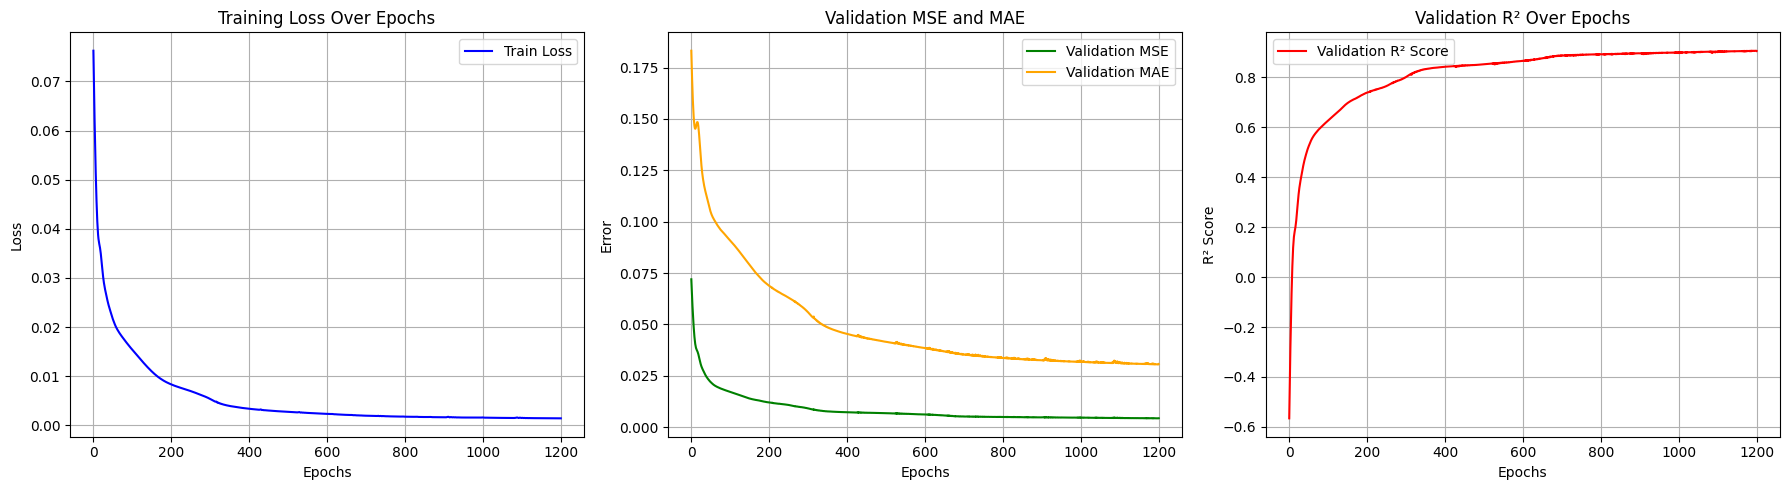

In [28]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.nn import GATConv
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Define the model
class GNNTransformerModel(nn.Module):
    def __init__(self, in_channels, hidden_dim, n_heads, n_transformer_layers):
        super().__init__()
        self.gnn = GATConv(in_channels, hidden_dim, heads=4, concat=False)
        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.gnn(x, edge_index))
        return self.regressor(x).view(-1)

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_train = data_train.to(device)
data_val = data_val.to(device)

model = GNNTransformerModel(
    in_channels=data_train.num_node_features,
    hidden_dim=128,
    n_heads=8,
    n_transformer_layers=2
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()

# Evaluation Function
def evaluate(model, data):
    model.eval()
    with torch.no_grad():
        y_pred = model(data).cpu().numpy()
        y_true = data.y.cpu().numpy()

        mse = mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)

        return {"MSE": mse, "MAE": mae, "R2": r2}

# Initialize trackers
train_losses = []
val_mses = []
val_maes = []
val_r2s = []
best_r2 = float("-inf")
best_model_state = None

# Training Loop
epochs = 1200
start_time = time.time()

for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    output = model(data_train)
    loss = criterion(output, data_train.y)
    loss.backward()
    optimizer.step()

    val_scores = evaluate(model, data_val)

    train_losses.append(loss.item())
    val_mses.append(val_scores["MSE"])
    val_maes.append(val_scores["MAE"])
    val_r2s.append(val_scores["R2"])

    if val_scores["R2"] > best_r2:
        best_r2 = val_scores["R2"]
        best_model_state = model.state_dict()

    if epoch % 5 == 0 or epoch == 1:
        print(f"[Epoch {epoch:03d}] Train Loss: {loss.item():.4f} | "
              f"Val MSE: {val_scores['MSE']:.4f}, MAE: {val_scores['MAE']:.4f}, R2: {val_scores['R2']:.4f}")

end_time = time.time()
print(f"\n✅ Training completed in {(end_time - start_time):.2f} seconds.")
print(f"📈 Best R2 achieved: {best_r2:.4f}")

# Load best model
model.load_state_dict(best_model_state)

# 📊 Plotting Results
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(val_mses, label='Validation MSE', color='green')
plt.plot(val_maes, label='Validation MAE', color='orange')
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.title("Validation MSE and MAE")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(val_r2s, label='Validation R² Score', color='red')
plt.xlabel("Epochs")
plt.ylabel("R² Score")
plt.title("Validation R² Over Epochs")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, global_mean_pool

# ⚡ Positional Encoding Block
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(0)  # shape: (1, max_len, d_model)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)

# ⚙️ GNN + Transformer Custom Model
class GNNTransformerModel(nn.Module):
    def __init__(self, in_channels, hidden_dim, n_heads, n_transformer_layers):
        super().__init__()

        # GNN block (Graph Attention Layer)
        self.gnn = GATConv(in_channels, hidden_dim, heads=4, concat=False)

        # Positional encoding for transformer
        self.pos_encoder = PositionalEncoding(hidden_dim)

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=n_heads,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_transformer_layers
        )

        # Regression head
        self.regressor = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        # Batch required for pooling (create dummy if missing)
        batch = data.batch if hasattr(data, 'batch') else torch.zeros(x.size(0), dtype=torch.long, device=x.device)

        # GNN Layer
        x = self.gnn(x, edge_index)  # [num_nodes, hidden_dim]
        x = F.relu(x)

        # Global mean pooling: aggregates node embeddings to graph-level
        x_pooled = global_mean_pool(x, batch)  # [batch_size, hidden_dim]

        # Transformer expects input of shape [batch, seq_len, dim]; we simulate seq_len=1
        x_trans = x_pooled.unsqueeze(1)  # [batch_size, 1, hidden_dim]
        x_trans = self.pos_encoder(x_trans)
        x_trans = self.transformer(x_trans)  # [batch_size, 1, hidden_dim]

        # Remove sequence dimension
        x_out = x_trans.squeeze(1)  # [batch_size, hidden_dim]

        # Predict regression output
        return self.regressor(x_out).view(-1)  # [batch_size]


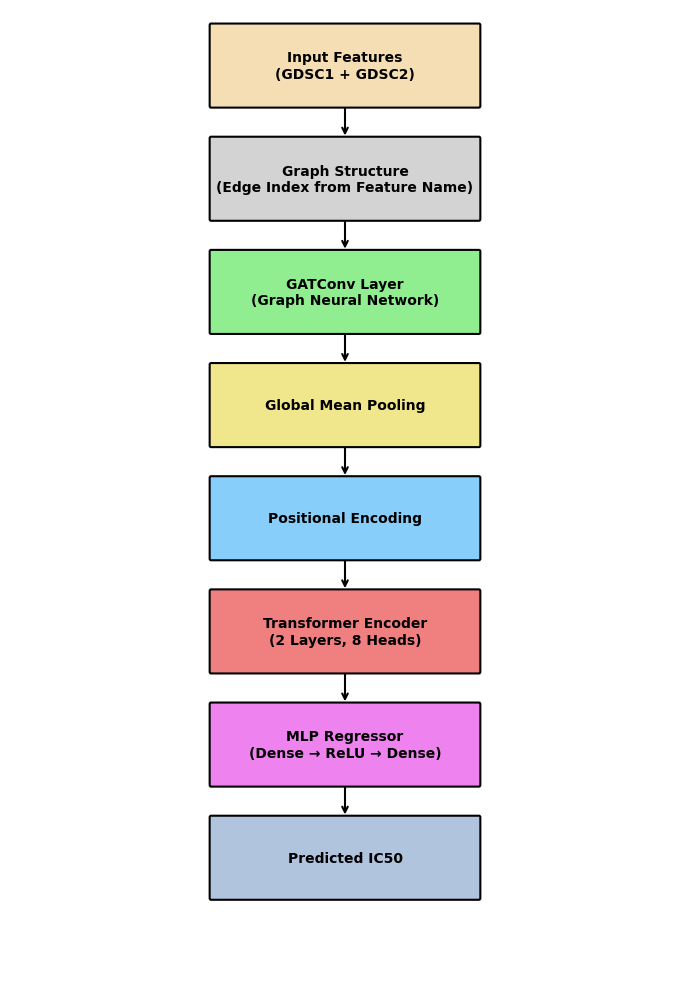

In [22]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

def draw_box(ax, text, xy, width, height, color='lightblue', fontsize=10):
    x, y = xy
    box = FancyBboxPatch((x, y), width, height,
                         boxstyle="round,pad=0.02", ec="black", fc=color, linewidth=1.5)
    ax.add_patch(box)
    ax.text(x + width/2, y + height/2, text, ha='center', va='center',
            fontsize=fontsize, weight='bold', wrap=True)

def draw_arrow(ax, xy_from, xy_to):
    ax.annotate("", xy_to, xy_from,
                arrowprops=dict(arrowstyle="->", lw=1.5))

fig, ax = plt.subplots(figsize=(7, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')

# Define box positions and properties
boxes = [
    ("Input Features\n(GDSC1 + GDSC2)", (3, 10.8), 'wheat'),
    ("Graph Structure\n(Edge Index from Feature Name)", (3, 9.4), 'lightgray'),
    ("GATConv Layer\n(Graph Neural Network)", (3, 8.0), 'lightgreen'),
    ("Global Mean Pooling", (3, 6.6), 'khaki'),
    ("Positional Encoding", (3, 5.2), 'lightskyblue'),
    ("Transformer Encoder\n(2 Layers, 8 Heads)", (3, 3.8), 'lightcoral'),
    ("MLP Regressor\n(Dense → ReLU → Dense)", (3, 2.4), 'violet'),
    ("Predicted IC50", (3, 1.0), 'lightsteelblue')
]

# Draw all boxes and arrows
box_width, box_height = 4, 1.0
for i, (text, pos, color) in enumerate(boxes):
    draw_box(ax, text, pos, box_width, box_height, color=color)
    if i < len(boxes) - 1:
        x_mid = pos[0] + box_width / 2
        y_bottom = pos[1]
        y_next_top = boxes[i+1][1][1] + box_height
        draw_arrow(ax, (x_mid, y_bottom), (x_mid, y_next_top))

plt.tight_layout()
plt.savefig("/content/GNN_Transformer_Model_Architecture_Diagram.png", dpi=300, bbox_inches='tight')
plt.show()


Shape of GDSC1: (200920, 20)
Shape of GDSC2: (269547, 20)
Combined Shape: (470467, 20)

Column Names:
 ['Drug name', 'Drug ID', 'Drug target', 'Target Pathway', 'Feature Name', 'n_feature_pos', 'n_feature_neg', 'ic50_effect_size', 'log_ic50_mean_pos', 'log_ic50_mean_neg', 'feature_ic50_t_pval', 'feature_delta_mean_ic50', 'feature_pos_ic50_var', 'feature_neg_ic50_var', 'feature_pval', 'tissue_pval', 'msi_pval', 'fdr', 'Tissue Type', 'Screening Set']

Data Types:
 Drug name                   object
Drug ID                      int64
Drug target                 object
Target Pathway              object
Feature Name                object
n_feature_pos                int64
n_feature_neg                int64
ic50_effect_size           float64
log_ic50_mean_pos          float64
log_ic50_mean_neg          float64
feature_ic50_t_pval        float64
feature_delta_mean_ic50    float64
feature_pos_ic50_var       float64
feature_neg_ic50_var       float64
feature_pval               float64
tissue_p

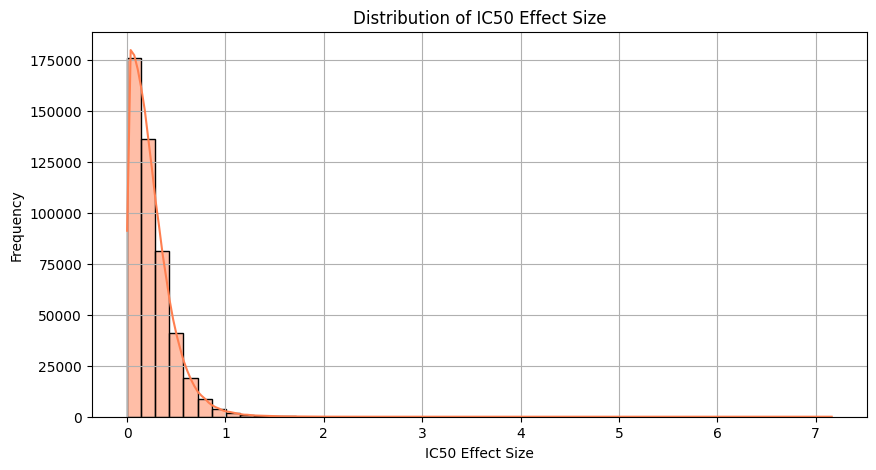

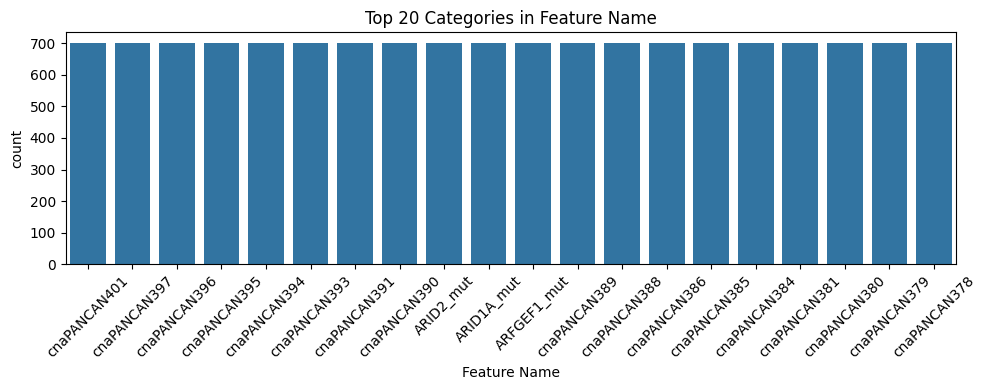

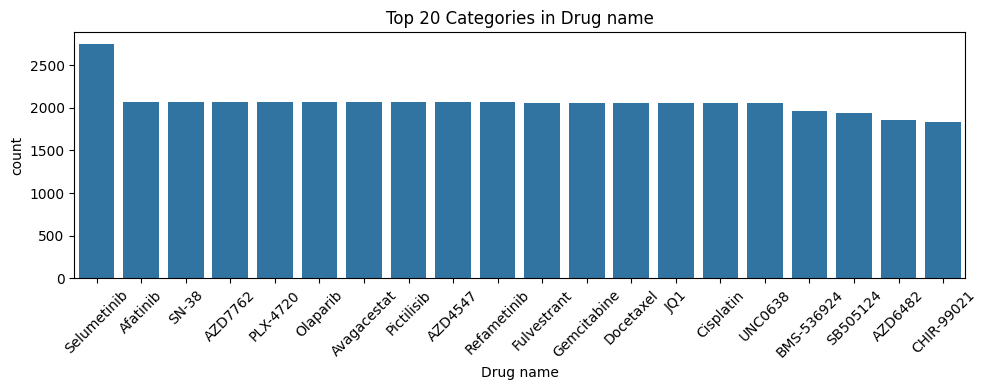

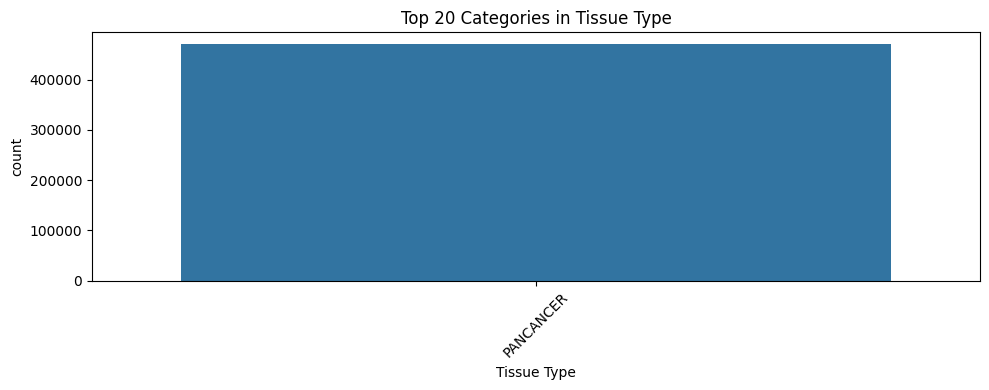

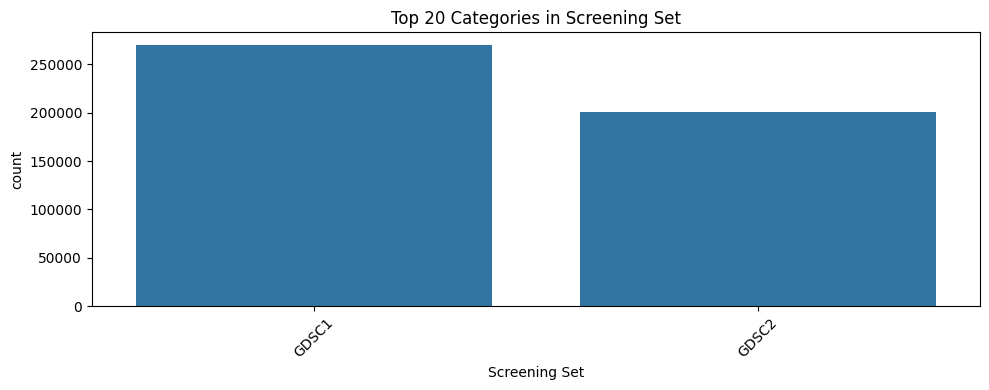

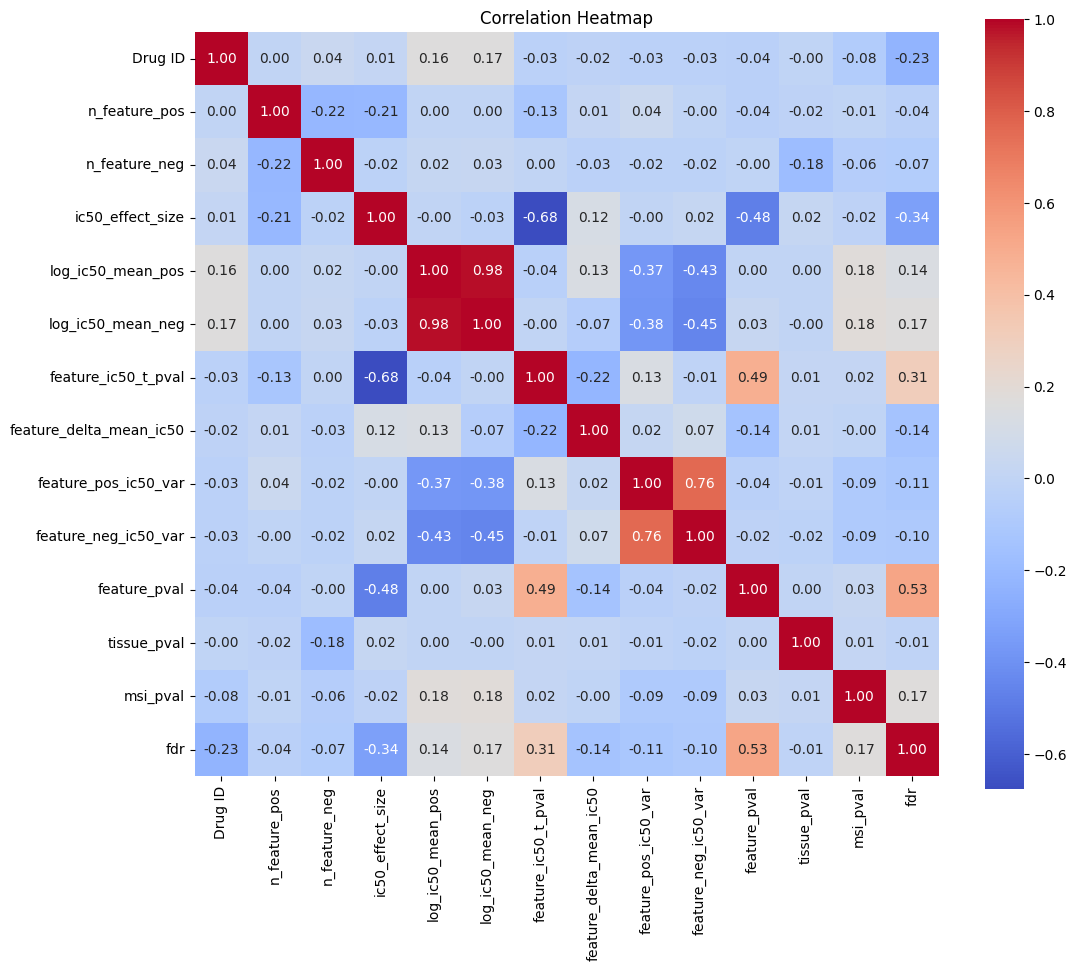

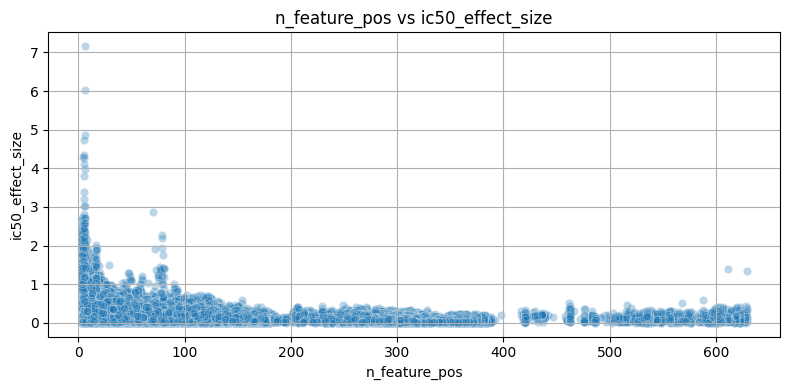

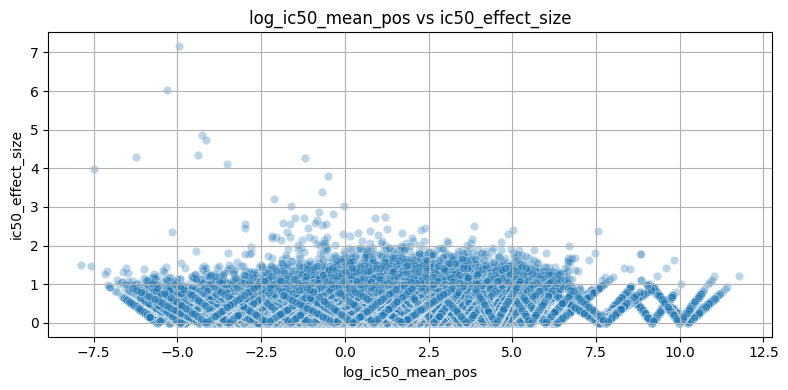

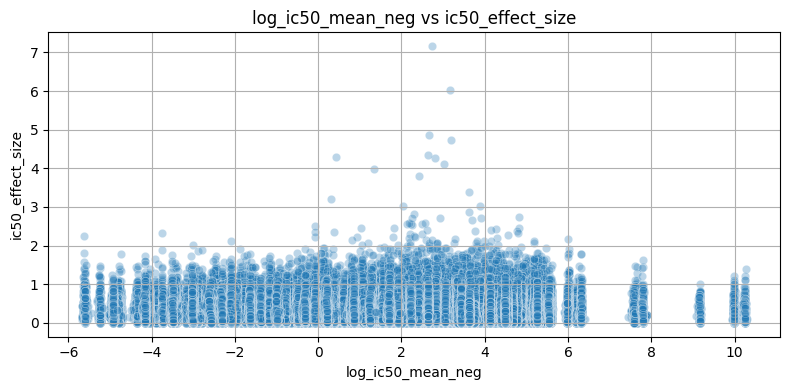

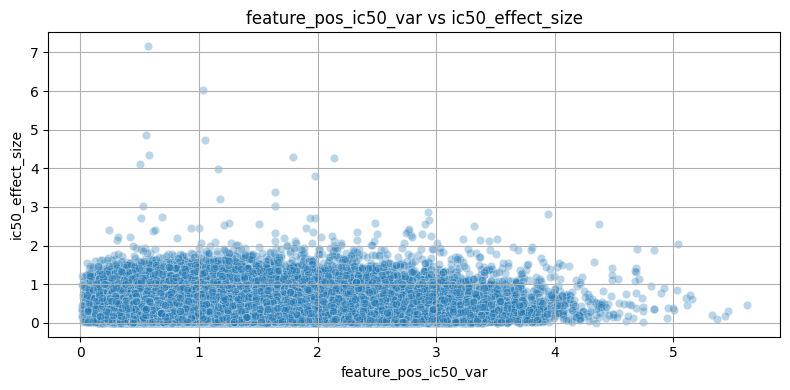

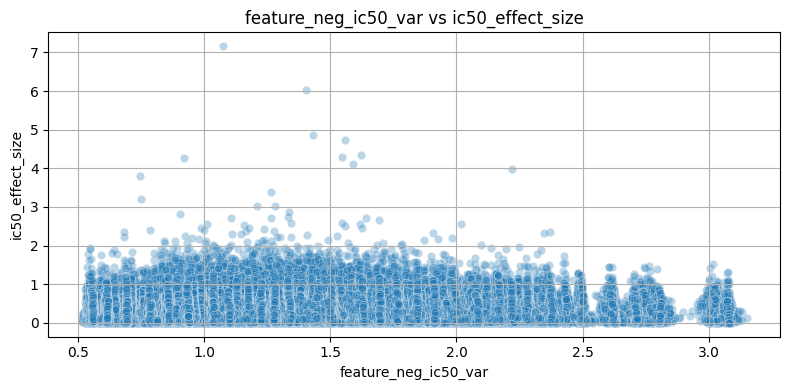

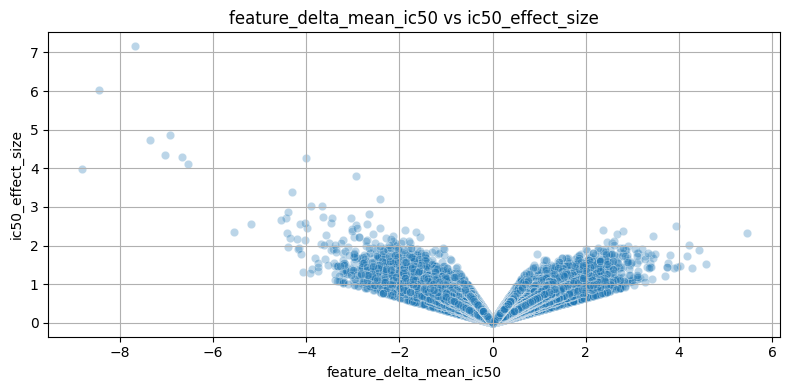

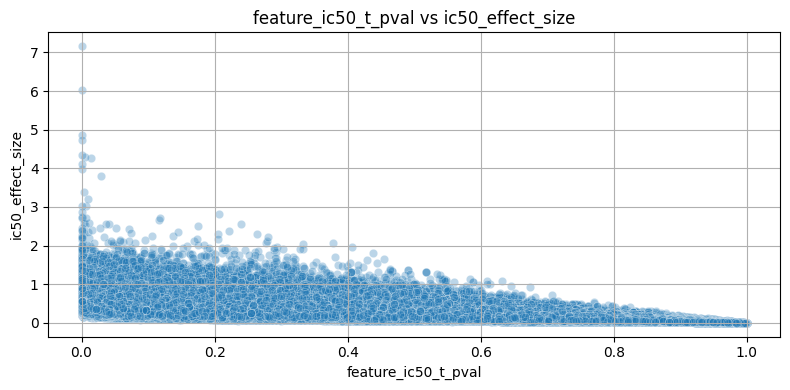

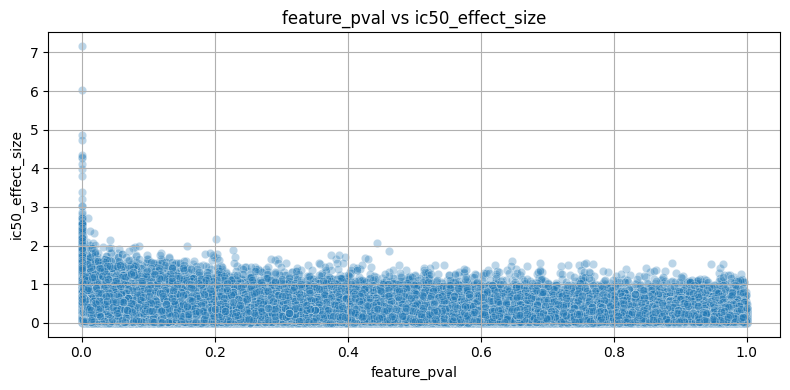

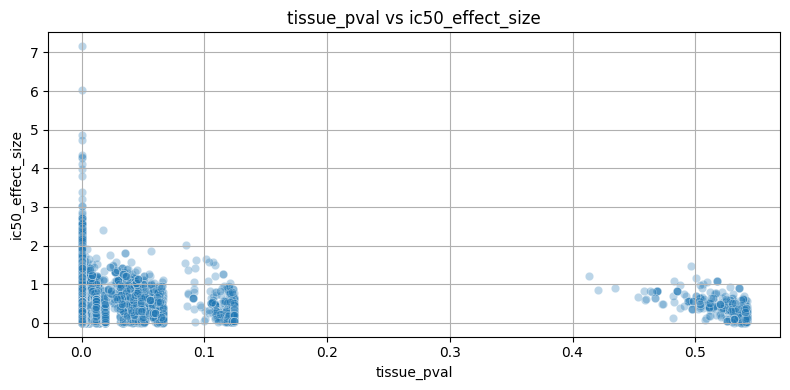

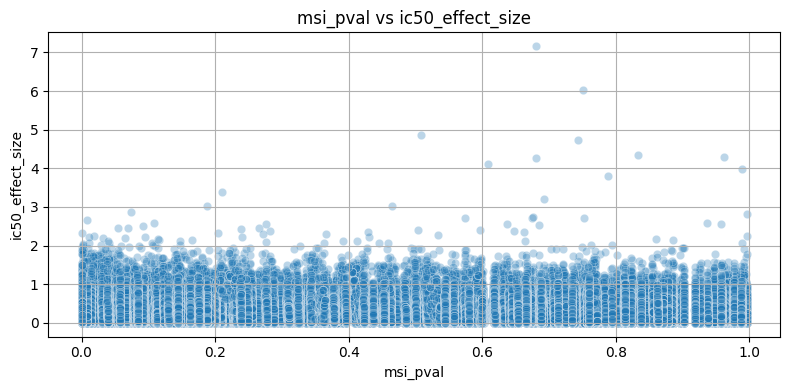

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load combined dataset
df1 = pd.read_csv("/content/GDSC1.csv", engine='python', on_bad_lines='skip')
df2 = pd.read_csv("/content/GDSC2.csv", engine='python', on_bad_lines='skip')

# Drop unnecessary columns
df1.drop(columns=['log_max_conc_tested','log_max_conc_tested_2'], inplace=True, errors='ignore')
df2.drop(columns=['log_max_conc_tested','log_max_conc_tested_2'], inplace=True, errors='ignore')

# Combine
df = pd.concat([df1, df2], ignore_index=True)

# -------------------------------
#  Basic Structure
# -------------------------------
print("Shape of GDSC1:", df1.shape)
print("Shape of GDSC2:", df2.shape)
print("Combined Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

# -------------------------------
#  Statistical Overview
# -------------------------------
print("\nDescriptive Stats:\n")
print(df.describe(include='all').T)

# -------------------------------
#  Target Distribution (ic50_effect_size)
# -------------------------------
if 'ic50_effect_size' in df.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(df['ic50_effect_size'], kde=True, bins=50, color='coral')
    plt.title("Distribution of IC50 Effect Size")
    plt.xlabel("IC50 Effect Size")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

# -------------------------------
#  Categorical Distribution
# -------------------------------
categorical_cols = ['Feature Name', 'Drug name', 'Tissue Type', 'Screening Set']
for col in categorical_cols:
    if col in df.columns:
        plt.figure(figsize=(10, 4))
        sns.countplot(data=df, x=col, order=df[col].value_counts().iloc[:20].index)
        plt.title(f"Top 20 Categories in {col}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# -------------------------------
#  Correlation Heatmap (Numerical)
# -------------------------------
numerical_cols = df.select_dtypes(include='number').columns.tolist()
plt.figure(figsize=(12, 10))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True, cbar=True)
plt.title("Correlation Heatmap")
plt.show()

# -------------------------------
#  IC50 vs Numerical Features
# -------------------------------
target = 'ic50_effect_size'
for col in feature_cols:
    if col in df.columns:
        plt.figure(figsize=(8, 4))
        sns.scatterplot(x=df[col], y=df[target], alpha=0.3)
        plt.title(f"{col} vs {target}")
        plt.xlabel(col)
        plt.ylabel(target)
        plt.grid(True)
        plt.tight_layout()
        plt.show()


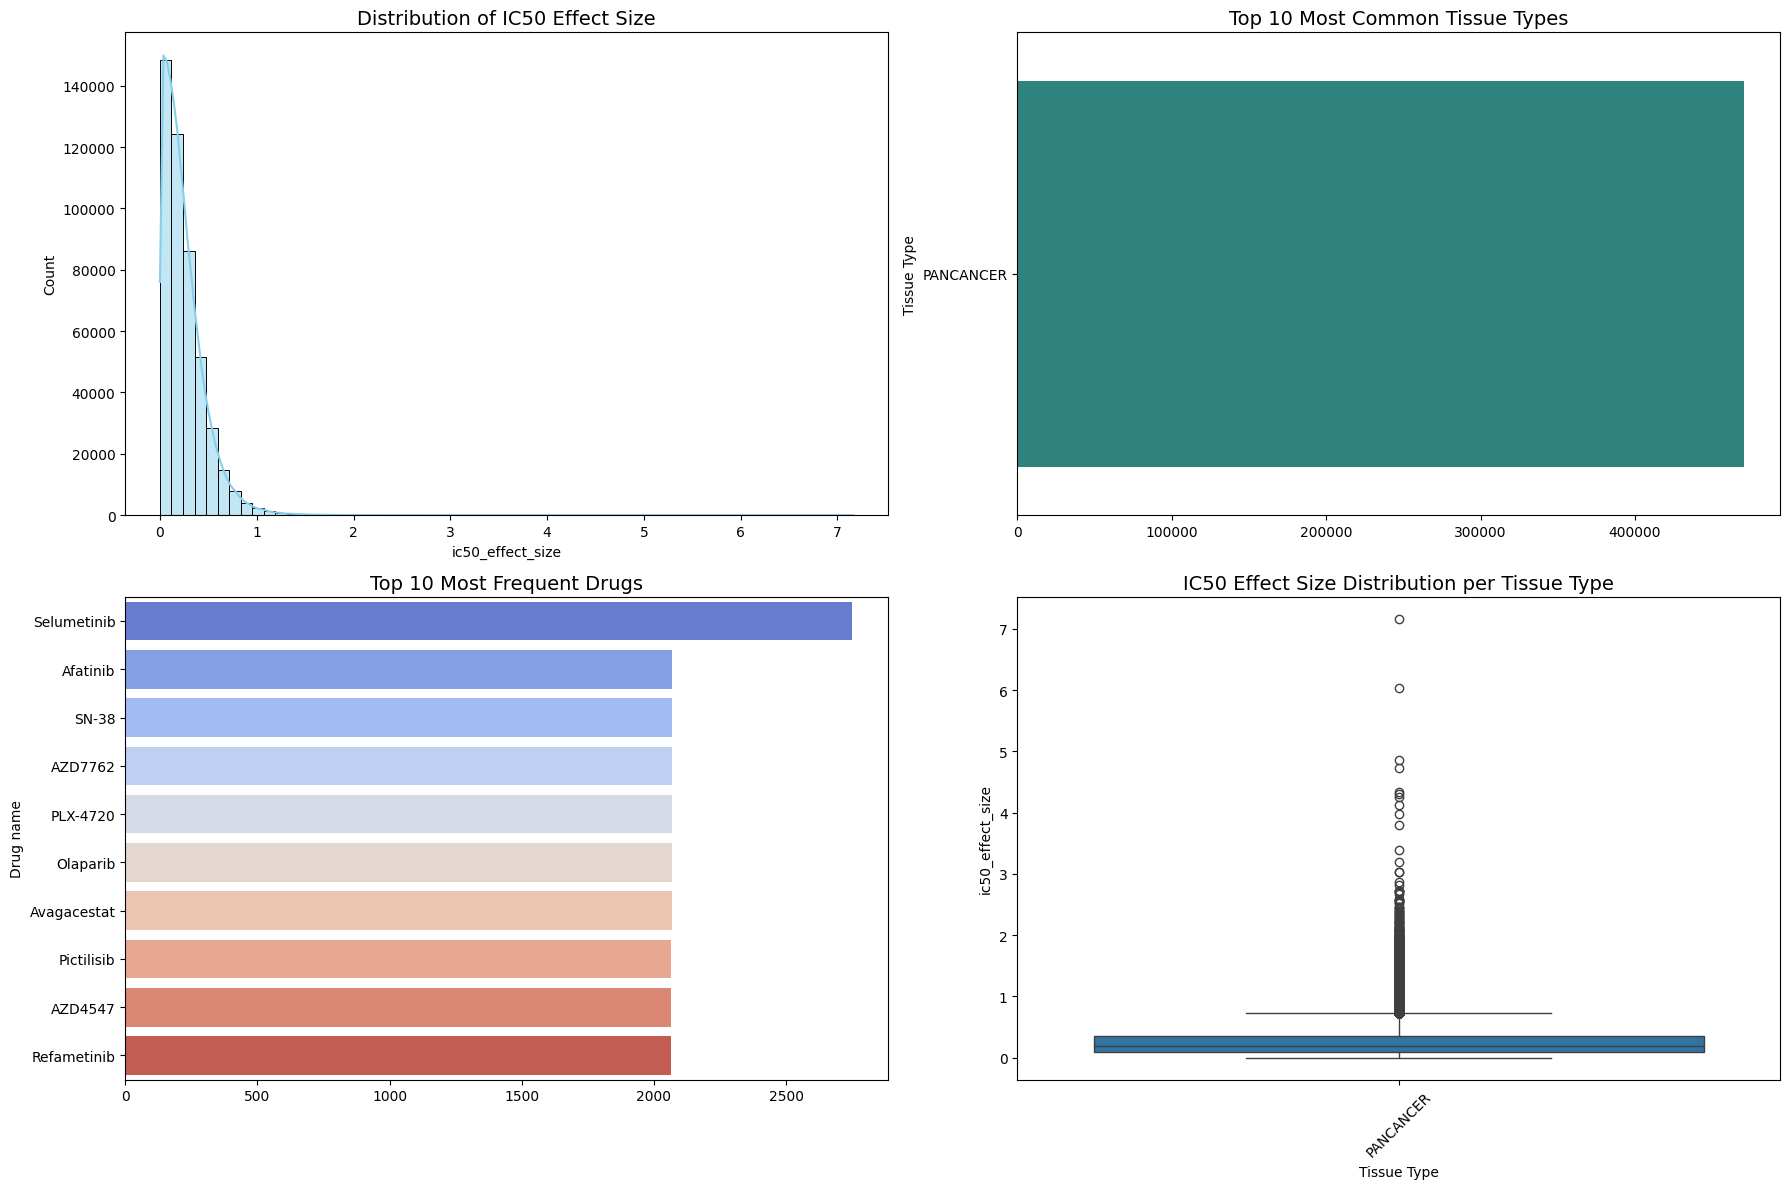

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load combined dataset for EDA visualizations
df1 = pd.read_csv("/content/GDSC1.csv", engine='python', on_bad_lines='skip')
df2 = pd.read_csv("/content/GDSC2.csv", engine='python', on_bad_lines='skip')

# Drop unnecessary columns
df1.drop(columns=['log_max_conc_tested','log_max_conc_tested_2'], inplace=True, errors='ignore')
df2.drop(columns=['log_max_conc_tested','log_max_conc_tested_2'], inplace=True, errors='ignore')

# Merge datasets
df = pd.concat([df1, df2], ignore_index=True)

# Fill missing values for plotting
df.fillna("Missing", inplace=True)

# Select a few useful plots for EDA
fig, axs = plt.subplots(2, 2, figsize=(18, 12))

# 1. Distribution of IC50 values
sns.histplot(df["ic50_effect_size"], kde=True, bins=60, ax=axs[0, 0], color="skyblue")
axs[0, 0].set_title("Distribution of IC50 Effect Size", fontsize=14)

# 2. Tissue Type distribution
if "Tissue Type" in df.columns:
    top_tissues = df["Tissue Type"].value_counts().nlargest(10)
    sns.barplot(x=top_tissues.values, y=top_tissues.index, ax=axs[0, 1], palette="viridis")
    axs[0, 1].set_title("Top 10 Most Common Tissue Types", fontsize=14)

# 3. Drug name counts
if "Drug name" in df.columns:
    top_drugs = df["Drug name"].value_counts().nlargest(10)
    sns.barplot(x=top_drugs.values, y=top_drugs.index, ax=axs[1, 0], palette="coolwarm")
    axs[1, 0].set_title("Top 10 Most Frequent Drugs", fontsize=14)

# 4. IC50 vs Tissue Type (Box Plot)
if "Tissue Type" in df.columns:
    selected_tissues = df[df["Tissue Type"].isin(top_tissues.index)]
    sns.boxplot(data=selected_tissues, x="Tissue Type", y="ic50_effect_size", ax=axs[1, 1])
    axs[1, 1].set_title("IC50 Effect Size Distribution per Tissue Type", fontsize=14)
    axs[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
